# Hybrid ARIMA-LSTM AQI Forecasting Model
**Real-World Application on India City Air Quality Data**


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
import pmdarima as pm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

SELECTED_CITIES = ['Delhi', 'Mumbai', 'Bengaluru']
AQI_POLLUTANTS = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
METEO_FEATURES = ['Temperature', 'Humidity', 'Wind_Speed']

## 1. Data Loading & Weather Augmentation


In [2]:
print("Loading real dataset...")
df_raw = pd.read_csv("city_day.csv/city_day.csv")
df_raw['Date'] = pd.to_datetime(df_raw['Date'])

df = df_raw[df_raw['City'].isin(SELECTED_CITIES)].copy()
df.rename(columns={'City': 'Zone'}, inplace=True)
df = df.sort_values(by=['Zone', 'Date']).reset_index(drop=True)

print("Augmenting with synthetic weather data...")
rng = np.random.default_rng(42)

WEATHER_PROFILES = {
    "Delhi": {"Temperature": (25, 10), "Humidity": (55, 20), "Wind_Speed": (8, 4)},
    "Mumbai": {"Temperature": (28, 4), "Humidity": (75, 10), "Wind_Speed": (15, 5)},
    "Bengaluru": {"Temperature": (24, 5), "Humidity": (65, 15), "Wind_Speed": (10, 4)},
}

for feature in METEO_FEATURES:
    df[feature] = np.nan

for city in SELECTED_CITIES:
    mask = df['Zone'] == city
    n = mask.sum()
    if n == 0: continue
    
    city_dates = df.loc[mask, 'Date']
    
    for feature in METEO_FEATURES:
        mean, std = WEATHER_PROFILES[city][feature]
        base = rng.normal(mean, std, size=n)
        
        if feature == "Temperature":
            doy = city_dates.dt.dayofyear.values.astype(float)
            temp_seasonal = mean + (std * 1.2) * np.sin(2 * np.pi * (doy - 100) / 365)
            signal = temp_seasonal + rng.normal(0, std * 0.3, size=n)
        elif feature == "Humidity":
            months = city_dates.dt.month.values
            monsoon = np.where((months >= 7) & (months <= 9), 1.3, 0.9)
            signal = base * monsoon
        elif feature == "Wind_Speed":
            signal = np.abs(base)
            
        signal_smoothed = pd.Series(signal).rolling(window=3, min_periods=1).mean().values
        df.loc[mask, feature] = np.round(signal_smoothed, 2)

display(df.head())

Loading real dataset...
Augmenting with synthetic weather data...


,Zone,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Temperature,Humidity,Wind_Speed
0,Bengaluru,2015-01-01,NaN,NaN,3.26,17.33,10.88,20.36,0.33,3.54,10.73,0.56,4.64,NaN,NaN,NaN,18.82,61.09,15.08
1,Bengaluru,2015-01-02,NaN,NaN,6.05,19.73,14.14,23.74,1.35,3.97,22.77,0.65,5.31,NaN,NaN,NaN,18.78,70.71,11.87
2,Bengaluru,2015-01-03,NaN,NaN,11.91,19.88,20.72,4.32,17.40,13.61,12.03,0.53,19.25,NaN,NaN,NaN,18.84,71.76,11.80
3,Bengaluru,2015-01-04,NaN,NaN,7.45,21.61,16.88,0.87,5.05,6.52,17.70,0.55,7.47,NaN,NaN,NaN,19.32,69.75,9.89
4,Bengaluru,2015-01-05,NaN,NaN,9.52,22.17,21.76,31.38,1.83,4.71,12.72,0.40,4.36,NaN,NaN,NaN,18.23,64.89,8.03


## 2. Data Preprocessing & Feature Engineering


In [3]:
print("Handling Missing Values...")
features = AQI_POLLUTANTS + METEO_FEATURES

for col in features:
    df[col] = df[col].interpolate(method='linear', limit=3, limit_direction='both')

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
df[features] = knn_imputer.fit_transform(df[features])
df[features] = df[features].ffill().bfill()

print("Capping Outliers (IQR Method)...")
for col in AQI_POLLUTANTS:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=max(lower, 0), upper=upper)

print("Imputing missing AQI values...")
df['AQI'] = df['AQI'].interpolate(method='linear').ffill().bfill()

print("Engineering Temporal & Rolling Features...")
for col in ['AQI', 'PM2.5', 'PM10']:
    df[f"{col}_MA7"] = df.groupby('Zone')[col].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df[f"{col}_MA30"] = df.groupby('Zone')[col].transform(lambda x: x.rolling(30, min_periods=1).mean())

df['AQI_lag1'] = df.groupby('Zone')['AQI'].shift(1)
df['AQI_roc'] = df.groupby('Zone')['AQI'].pct_change()
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Month'] = df['Date'].dt.month

df = df.bfill().ffill()
display(df.head())

Handling Missing Values...


Capping Outliers (IQR Method)...
Imputing missing AQI values...
Engineering Temporal & Rolling Features...


,Zone,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,AQI_MA7,AQI_MA30,PM2.5_MA7,PM2.5_MA30,PM10_MA7,PM10_MA30,AQI_lag1,AQI_roc,DayOfWeek,Month
0,Bengaluru,2015-01-01,17.729944,64.072953,3.26,17.33,10.88,20.36,0.33,3.54,...,91.0,91.0,17.729944,17.729944,64.072953,64.072953,91.0,0.0,3,1
1,Bengaluru,2015-01-02,28.708723,49.679309,6.05,19.73,14.14,23.74,1.35,3.97,...,91.0,91.0,23.219333,23.219333,56.876131,56.876131,91.0,0.0,4,1
2,Bengaluru,2015-01-03,23.144303,70.010177,11.91,19.88,20.72,4.32,2.93,13.61,...,91.0,91.0,23.194323,23.194323,61.254146,61.254146,91.0,0.0,5,1
3,Bengaluru,2015-01-04,32.905659,42.662275,7.45,21.61,16.88,0.87,2.93,6.52,...,91.0,91.0,25.622157,25.622157,56.606179,56.606179,91.0,0.0,6,1
4,Bengaluru,2015-01-05,33.049777,60.132376,9.52,22.17,21.76,31.38,1.83,4.71,...,91.0,91.0,27.107681,27.107681,57.311418,57.311418,91.0,0.0,0,1


## 3. Exploratory Data Analysis


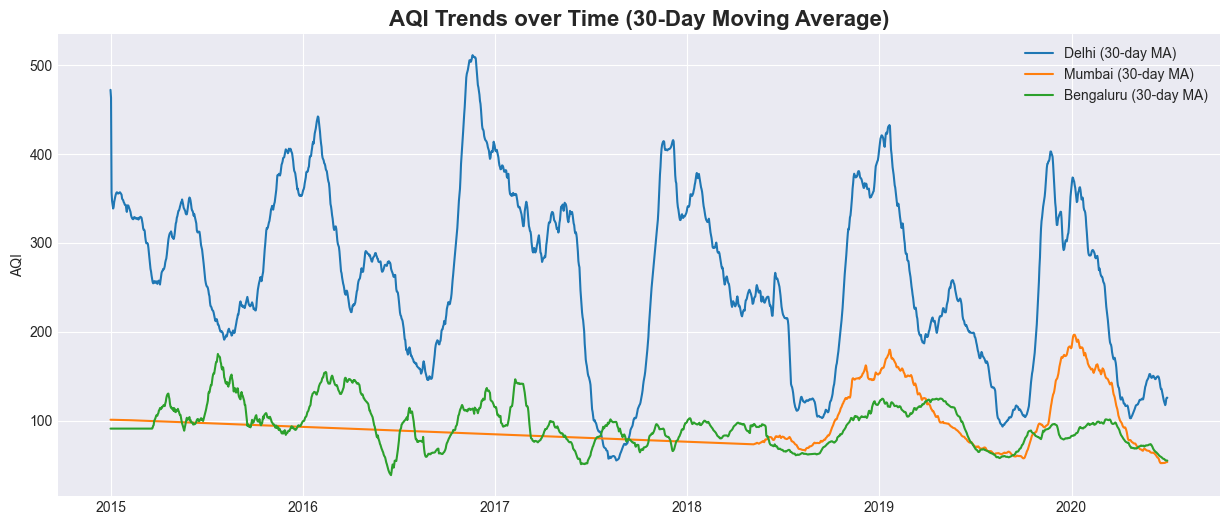

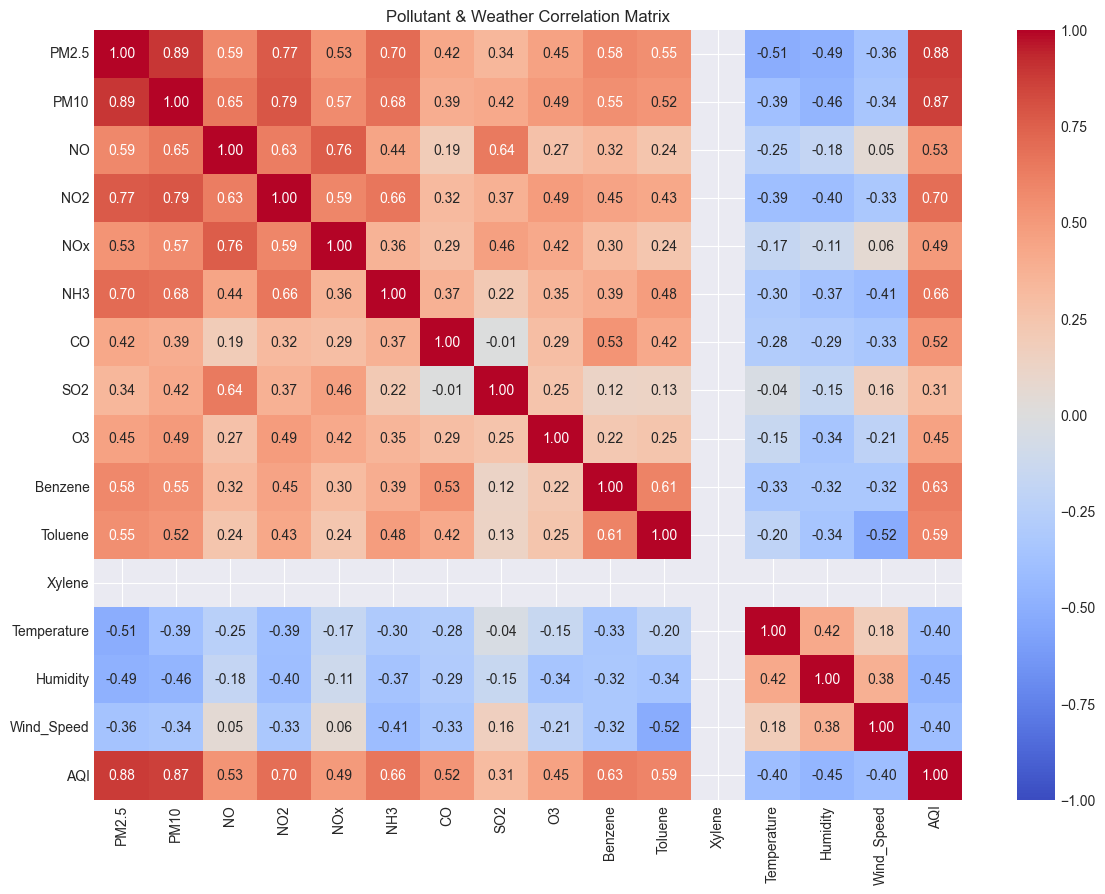

In [4]:
plt.figure(figsize=(15, 6))
for city in SELECTED_CITIES:
    city_data = df[df['Zone'] == city]
    plt.plot(city_data['Date'], city_data['AQI_MA30'], label=f"{city} (30-day MA)")

plt.title('AQI Trends over Time (30-Day Moving Average)', fontsize=16, fontweight='bold')
plt.ylabel('AQI')
plt.legend()
plt.show()

plt.figure(figsize=(14, 10))
corr = df[features + ['AQI']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Pollutant & Weather Correlation Matrix')
plt.show()

## 4. Feature Selection


In [5]:
candidate_features = [c for c in df.columns if c not in ['Date', 'Zone', 'AQI', 'AQI_Category', 'AQI_Bucket']]

corr_with_aqi = df[candidate_features].corrwith(df['AQI']).abs()
top_corr_features = corr_with_aqi[corr_with_aqi > 0.1].index.tolist()

print(f"Features selected: {len(top_corr_features)}")
SELECTED_FEATURES = top_corr_features

Features selected: 22


## 5. Statistical Baseline & Deep Learning (ARIMA + LSTM)
We will now loop through **ALL SELECTED CITIES** (Delhi, Mumbai, Bengaluru). For each city, we will:
1. Train a statistical ARIMA model to capture baseline linear trends.
2. Train a Deep Learning LSTM to predict the remaining nonlinear residual errors.
3. Combine them for a final Hybrid Forecast.



 MODELING PIPELINE FOR: Delhi 

[1] Training ARIMA Baseline for Delhi...



[2] Training LSTM Error Correction for Delhi...



[3] Evaluating Forecasts for Delhi...
   ARIMA (Standalone) -> RMSE: 115.80 | MAE: 92.51 | MAPE: 54.68%
   Hybrid ARIMA-LSTM  -> RMSE: 108.56 | MAE: 85.45 | MAPE: 49.67%


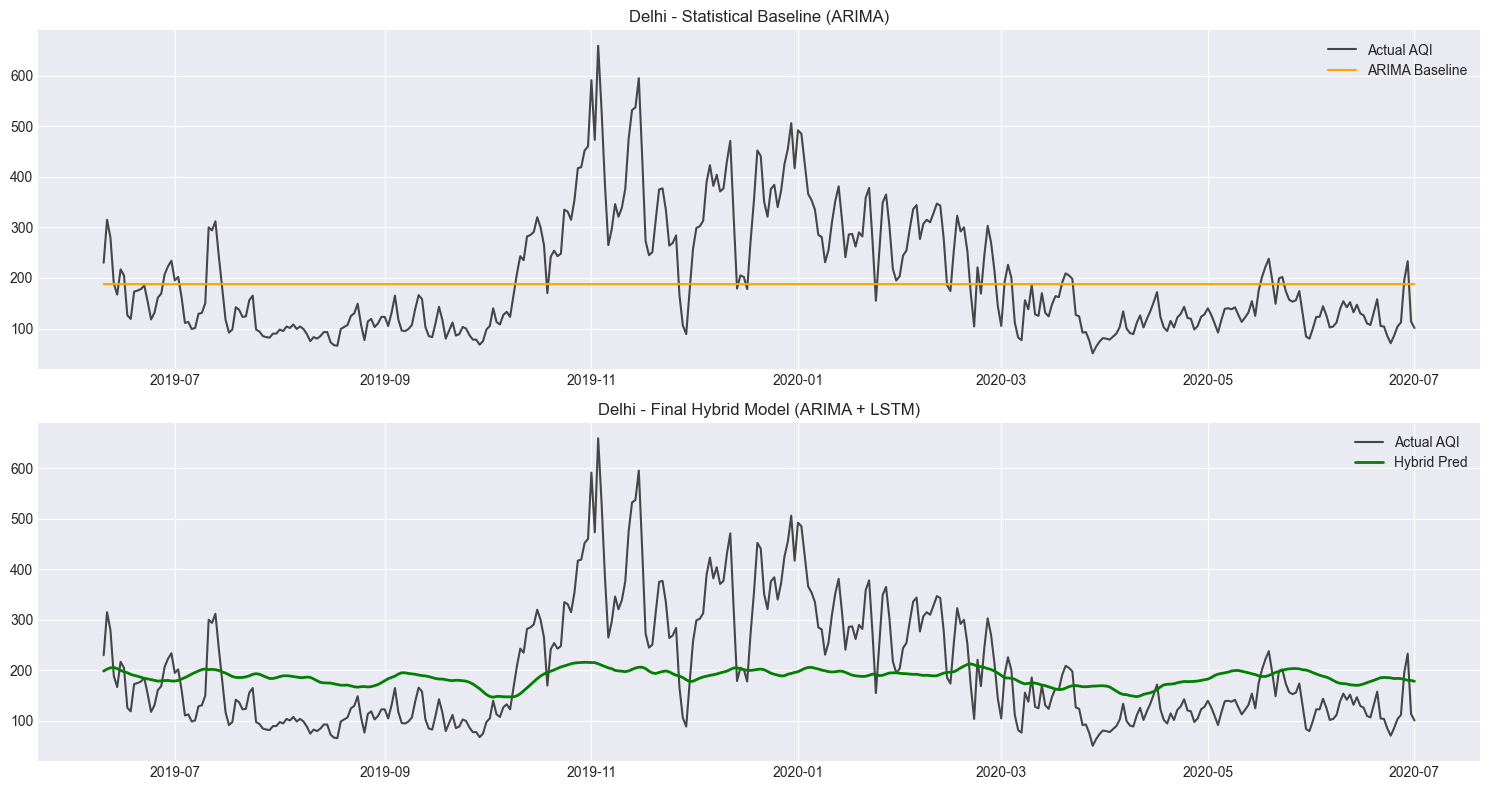


 MODELING PIPELINE FOR: Mumbai 

[1] Training ARIMA Baseline for Mumbai...



[2] Training LSTM Error Correction for Mumbai...



[3] Evaluating Forecasts for Mumbai...
   ARIMA (Standalone) -> RMSE: 54.25 | MAE: 39.89 | MAPE: 38.30%
   Hybrid ARIMA-LSTM  -> RMSE: 53.29 | MAE: 39.22 | MAPE: 37.70%


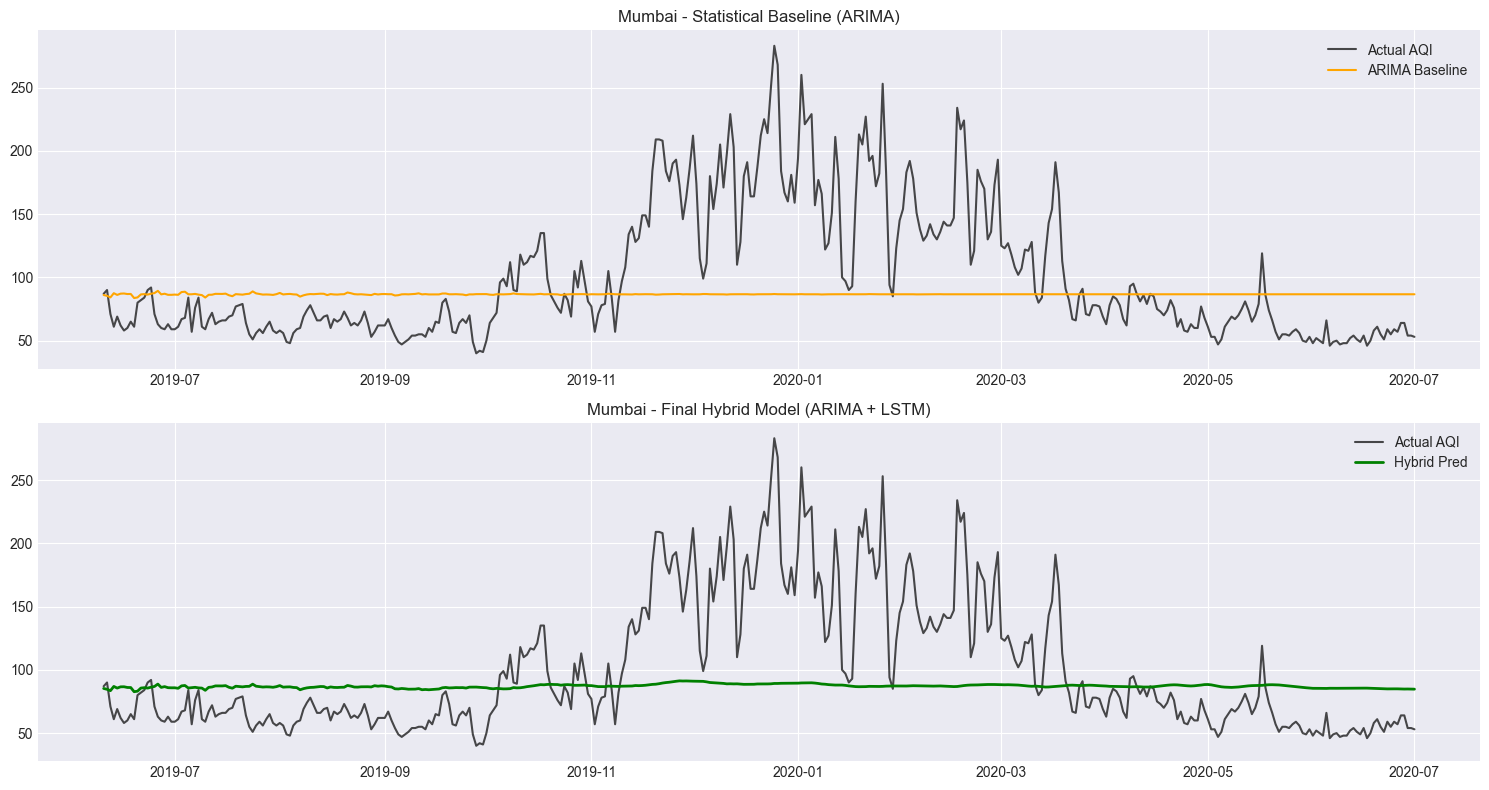


 MODELING PIPELINE FOR: Bengaluru 

[1] Training ARIMA Baseline for Bengaluru...



[2] Training LSTM Error Correction for Bengaluru...



[3] Evaluating Forecasts for Bengaluru...
   ARIMA (Standalone) -> RMSE: 35.36 | MAE: 31.81 | MAPE: 48.05%
   Hybrid ARIMA-LSTM  -> RMSE: 25.88 | MAE: 21.99 | MAPE: 32.94%


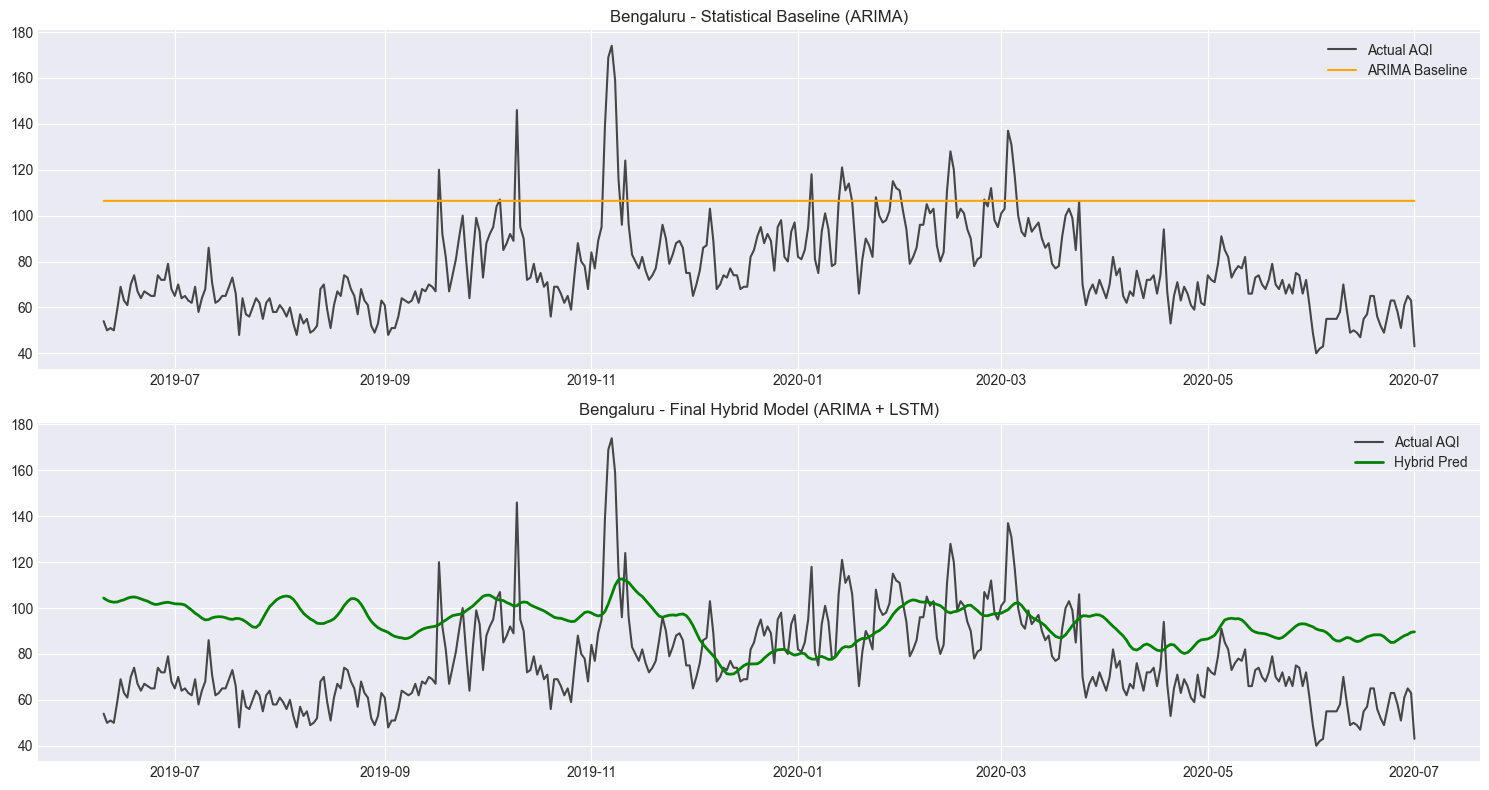


✅ All cities processed successfully!


In [6]:
def create_sequences(data, target, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
        ys.append(target[i + seq_length])
    return np.array(xs), np.array(ys)

def calc_metrics(actual, pred):
    mae = np.mean(np.abs(actual - pred))
    rmse = np.sqrt(np.mean((actual - pred)**2))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, rmse, mape

SEQ_LENGTH = 14

for city in SELECTED_CITIES:
    print("\n" + "="*80)
    print(f"\033[1m MODELING PIPELINE FOR: {city} \033[0m")
    print("="*80)
    
    city_df = df[df['Zone'] == city].copy()
    city_df.set_index('Date', inplace=True)
    city_df = city_df.asfreq('D')
    
    # Train/Test Split (80/20)
    train_size = int(len(city_df) * 0.8)
    train, test = city_df.iloc[:train_size].copy(), city_df.iloc[train_size:].copy()
    
    print(f"\n[1] Training ARIMA Baseline for {city}...")
    arima_model = pm.auto_arima(
        train['AQI'],
        start_p=1, start_q=1, max_p=3, max_q=3, d=1,
        seasonal=True, m=7, 
        trace=False, error_action='ignore', suppress_warnings=True, stepwise=True
    )
    
    forecast = arima_model.predict(n_periods=len(test))
    test['ARIMA_Pred'] = forecast
    
    # Extract Residuals
    train['Residuals'] = train['AQI'] - arima_model.predict_in_sample()
    test['Residuals'] = test['AQI'] - test['ARIMA_Pred']
    
    print(f"\n[2] Training LSTM Error Correction for {city}...")
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    train_X_scaled = scaler_X.fit_transform(train[SELECTED_FEATURES])
    test_X_scaled = scaler_X.transform(test[SELECTED_FEATURES])

    train_y_scaled = scaler_y.fit_transform(train[['Residuals']])
    test_y_scaled = scaler_y.transform(test[['Residuals']])

    X_train_seq, y_train_seq = create_sequences(train_X_scaled, train_y_scaled, SEQ_LENGTH)
    X_test_seq, y_test_seq = create_sequences(test_X_scaled, test_y_scaled, SEQ_LENGTH)

    model = Sequential([
        Input(shape=(SEQ_LENGTH, len(SELECTED_FEATURES))),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    model.fit(
        X_train_seq, y_train_seq,
        validation_split=0.2,
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Predict residuals
    lstm_pred_scaled = model.predict(X_test_seq, verbose=0)
    lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled).flatten()

    aligned_actual = test['AQI'].iloc[SEQ_LENGTH:].values
    aligned_arima = test['ARIMA_Pred'].iloc[SEQ_LENGTH:].values

    hybrid_pred = aligned_arima + lstm_pred
    
    # Metrics
    print(f"\n[3] Evaluating Forecasts for {city}...")
    arima_mae, arima_rmse, arima_mape = calc_metrics(aligned_actual, aligned_arima)
    hybrid_mae, hybrid_rmse, hybrid_mape = calc_metrics(aligned_actual, hybrid_pred)

    print(f"   ARIMA (Standalone) -> RMSE: {arima_rmse:.2f} | MAE: {arima_mae:.2f} | MAPE: {arima_mape:.2f}%")
    print(f"   Hybrid ARIMA-LSTM  -> RMSE: {hybrid_rmse:.2f} | MAE: {hybrid_mae:.2f} | MAPE: {hybrid_mape:.2f}%")
    
    # Plotting
    plt.figure(figsize=(15, 8))
    plt.subplot(2, 1, 1)
    plt.plot(test.index[SEQ_LENGTH:], aligned_actual, label='Actual AQI', color='black', alpha=0.7)
    plt.plot(test.index[SEQ_LENGTH:], aligned_arima, label='ARIMA Baseline', color='orange')
    plt.legend()
    plt.title(f'{city} - Statistical Baseline (ARIMA)')
    
    plt.subplot(2, 1, 2)
    plt.plot(test.index[SEQ_LENGTH:], aligned_actual, label='Actual AQI', color='black', alpha=0.7)
    plt.plot(test.index[SEQ_LENGTH:], hybrid_pred, label='Hybrid Pred', color='green', linewidth=2)
    plt.legend()
    plt.title(f'{city} - Final Hybrid Model (ARIMA + LSTM)')
    
    plt.tight_layout()
    plt.show()

print("\n✅ All cities processed successfully!")